##1. 데이터 세트 로딩 및 타깃 변수(Price) 분포 확인

제품 가격(Price)을 예측하는 회귀 문제이기 때문에,

정형 속성(브랜드, 카테고리)과 비정형 텍스트 속성(제품 설명)을 동시에 활용함.

회귀 모델에서 타깃 값의 정규 분포는 매우 중요하므로, 한쪽으로 치우친(Skewed) Price 값에 로그 변환(log1p)을 취해 정규 분포 형태로 유도함.

(74179, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3.0,Men/Tops/T-shirts,NaN,10.0,1.0,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3.0,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0.0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1.0,Women/Tops & Blouses/Blouse,Target,10.0,1.0,Adorable top with a hint of lace and a key hol...


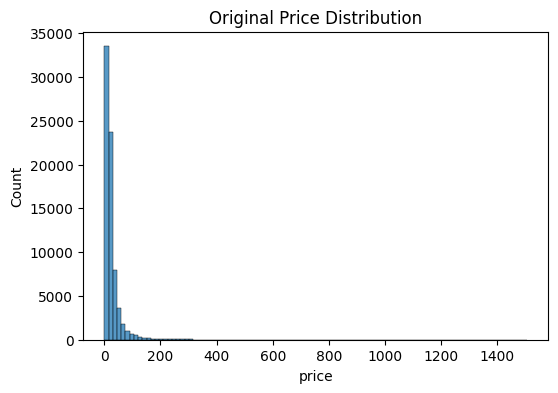

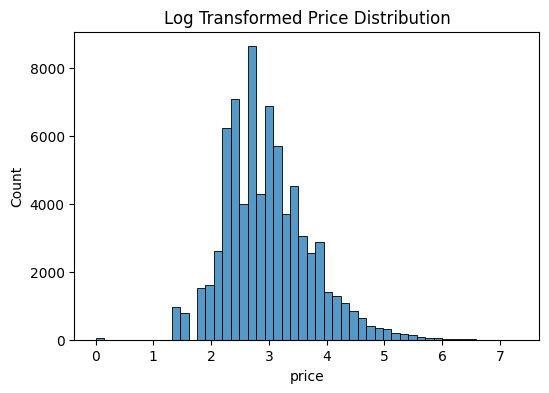

0    2.397895
1    3.970292
2    2.397895
Name: price, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 데이터 로딩
mercari_df = pd.read_csv('train.tsv', sep='\t')
print(mercari_df.shape)
display(mercari_df.head(3))

# Price 칼럼의 데이터 분포도 확인
plt.figure(figsize=(6, 4))
sns.histplot(mercari_df['price'], bins=100)
plt.title('Original Price Distribution')
plt.show()

# 로그 변환(log1p) 적용 후 정규 분포 형태 확인 및 데이터 세트 업데이트
mercari_df['price'] = np.log1p(mercari_df['price'])

plt.figure(figsize=(6, 4))
sns.histplot(mercari_df['price'], bins=50)
plt.title('Log Transformed Price Distribution')
plt.show()

print(mercari_df['price'].head(3))

##2. 데이터 전처리 (Null 값 처리 및 카테고리 분할)

텍스트와 범주형 데이터의 결측치(Null)를 의미 있는 다른 값(Other_Null)으로 치환함.

category_name은 대/중/소분류가 / 기호로 연결되어 있으므로, 이를 분리하여 각각 별도의 피처(cat_dae, cat_jung, cat_so)로 독립시킴.

In [ ]:
# Shipping 및 item_condition_id 값 유형 확인
print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n', mercari_df['item_condition_id'].value_counts())

# item_description이 'No description yet'인 경우 확인
boolean_cond = mercari_df['item_description'] == 'No description yet'
print("'No description yet' 건수:", mercari_df[boolean_cond]['item_description'].count())

# apply lambda에서 호출되는 대, 중, 소 분할 함수 생성
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null', 'Other_Null', 'Other_Null']

# zip과 *를 이용해 분리된 리스트를 대, 중, 소 칼럼으로 할당
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
    zip(*mercari_df['category_name'].apply(lambda x: split_cat(x)))

print('대분류 유형 :\n', mercari_df['cat_dae'].value_counts())
print('중분류 개수 :', mercari_df['cat_jung'].nunique())
print('소분류 개수 :', mercari_df['cat_so'].nunique())

# Null 값을 'Other_Null'로 일괄 변경
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 각 칼럼별 Null 건수 확인 (모두 0이 나와야 정상)
print('\nNull 값 건수 확인:\n', mercari_df.isnull().sum())

Shipping 값 유형:
 shipping
0.0    40978
1.0    33200
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1.0    31976
3.0    21578
2.0    18881
4.0     1613
5.0      130
Name: count, dtype: int64
'No description yet' 건수: 4243
대분류 유형 :
 cat_dae
Women                     33278
Beauty                    10465
Kids                       8567
Electronics                6203
Men                        4555
Home                       3326
Vintage & Collectibles     2361
Other                      2261
Handmade                   1579
Sports & Outdoors          1252
Other_Null                  332
Name: count, dtype: int64
중분류 개수 : 112
소분류 개수 : 675

Null 값 건수 확인:
 train_id             0
name                 0
item_condition_id    1
category_name        0
brand_name           0
price                1
shipping             1
item_description     0
cat_dae              0
cat_jung             0
cat_so               0
dtype: int64


##3. 텍스트 피처 벡터화 및 범주형 데이터 인코딩

길이가 짧고 명사가 위주인 제품명(name)은 Count 기반 벡터화를 적용함.

문장으로 이루어져 길이가 긴 제품 설명(item_description)은 TF-IDF 기반 벡터화를 적용함.

선형 회귀에 적합하도록 나머지 범주형 칼럼들은 원-핫 인코딩(One-Hot Encoding)을 수행함.

텍스트 벡터화 결과가 희소 행렬(Sparse Matrix)이므로, 메모리 효율을 위해 범주형 데이터 인코딩에도 희소 행렬을 반환하는 LabelBinarizer(sparse_output=True)를 사용함.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer

# LabelBinarizer는 NaN을 처리할 수 없으므로 남은 결측치를 처리합니다.
# item_condition_id와 shipping의 결측치를 0으로 채웁니다.
mercari_df['item_condition_id'] = mercari_df['item_condition_id'].fillna(0)
mercari_df['shipping'] = mercari_df['shipping'].fillna(0)
# price에 NaN이 있으면 학습이 불가능하므로 결측치가 있는 행을 제거하거나 채웁니다.
mercari_df = mercari_df.dropna(subset=['price'])

# name 속성에 대한 피처 벡터화 (CountVectorizer)
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df['name'])

# item_description에 대한 피처 벡터화 (TfidfVectorizer)
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1, 3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

# 범주형 피처들을 희소 행렬 원-핫 인코딩으로 변환
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])

lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])

lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# 대/중/소 카테고리 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])

lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

name vectorization shape: (74178, 21840)
item_description vectorization shape: (74178, 50000)
<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(74178, 1816), X_item_cond_id shape:(74178, 5)
X_shipping shape:(74178, 1), X_cat_dae shape:(74178, 11)
X_cat_jung shape:(74178, 112), X_cat_so shape:(74178, 675)


##4. 평가 로직 및 통합 모델링 함수 생성

평가지표로 RMSLE(Root Mean Square Logarithmic Error)를 사용함. 가격 편차가 큰 회귀 문제에서 높은 가격의 오차가 전체 지표를 압도하는 것을 방지함.

학습 시 Price를 log1p로 변환했으므로, 모델이 예측한 결과와 실제 평가를 위해 expm1으로 역변환(지수 변환)한 뒤 RMSLE를 계산해야 함.

scipy.sparse.hstack을 활용하여 앞서 만든 여러 개의 희소 행렬(텍스트 벡터, 원-핫 인코딩 행렬)을 하나의 거대한 칼럼 레벨 행렬로 결합함.

In [ ]:
import gc
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split

def rmsle(y, y_pred):
    # underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle 계산
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):
    # 원본 데이터는 log1p로 변환되었으므로 expm1로 역변환하여 원복 필요
    preds_exmpm = np.expm1(preds)
    y_test_exmpm = np.expm1(y_test)

    # rmsle로 RMSLE 값 추출
    rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
    return rmsle_result

def model_train_predict(model, matrix_list):
    # scipy.sparse 모듈의 hstack을 이용해 희소 행렬을 열 단위로 결합
    X = hstack(matrix_list).tocsr()

    # 학습 및 테스트 데이터 세트 분리
    X_train, X_test, y_train, y_test = train_test_split(X, mercari_df['price'],
                                                        test_size=0.2, random_state=156)
    # 모델 학습 및 예측
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # 메모리 관리를 위해 사용 완료한 객체 삭제
    del X, X_train, X_test, y_train
    gc.collect()

    return preds, y_test

##5. 릿지(Ridge) 회귀 모델 평가 및 텍스트 피처 영향도 분석

희소 행렬 데이터에 적합한 선형 회귀 모델인 Ridge를 적용함.

모델에 item_description(제품 설명) 피처를 포함했을 때와 제외했을 때의 성능을 비교하여, 텍스트 데이터가 회귀 예측(가격 결정)에 미치는 중요도를 직접 확인함.

In [ ]:
from sklearn.linear_model import Ridge

linear_model = Ridge(solver="lsqr", fit_intercept=False)

# 1. Item Description을 제외한 희소 행렬 리스트 구성
sparse_matrix_list_no_desc = (X_name, X_brand, X_item_cond_id,
                              X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds_no_desc, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list_no_desc)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds_no_desc))

# 2. Item Description을 포함한 희소 행렬 리스트 구성
sparse_matrix_list_with_desc = (X_descp, X_name, X_brand, X_item_cond_id,
                                X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list_with_desc)
print('Item Description을 포함한 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.54367020691407
Item Description을 포함한 rmsle 값: 0.5292536234010841


##6. LightGBM 모델 구축 및 앙상블(Ensemble) 예측
[이론 및 프로세스 정리]

트리 기반 부스팅 알고리즘인 LightGBM을 추가로 학습함.

선형 모델(Ridge)의 예측값과 트리 모델(LightGBM)의 예측값을 가중 평균(Weighted Average) 방식으로 섞어 단일 모델의 한계를 보완하고 최종 예측 성능을 더욱 끌어올림.

In [ ]:
from lightgbm import LGBMRegressor

# LightGBM 회귀 모델 학습
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
lgbm_preds, y_test = model_train_predict(model=lgbm_model, matrix_list=sparse_matrix_list_with_desc)
print('LightGBM rmsle 값:', evaluate_org_price(y_test, lgbm_preds))

# 릿지(Ridge)와 LightGBM의 예측값을 혼합하는 앙상블 적용 (가중치: LightGBM 0.45, Ridge 0.55)
# 앞선 셀에서 구한 linear_preds를 활용합니다.
preds = lgbm_preds * 0.45 + linear_preds * 0.55
print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값:', evaluate_org_price(y_test, preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 13.129008 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 276731
[LightGBM] [Info] Number of data points in the train set: 59342, number of used features: 10955
[LightGBM] [Info] Start training from score 2.978402
LightGBM rmsle 값: 0.5629056726946021
LightGBM과 Ridge를 ensemble한 최종 rmsle 값: 0.5128727229172602
